# Demo Finetune

This notebook is set up for `Run All`. Most users only need to fill in four lines: a workspace folder, a raw training folder, a ground-truth mask folder, and an inference folder.

If the three input folders are left as `None`, the notebook falls back to the staged VESSEL12 example. The full fine-tuning pipeline still lives in the `train/finetune/` subdirectory.


## User Settings

Fill in the four lines in the next cell before running the notebook. Leave the three input folders as `None` to run the staged VESSEL12 example instead.

- `WORKSPACE_DIR`: where the notebook stores managed copies of data, nnU-Net files, checkpoints, and predictions
- `TRAINING_RAW_INPUT_DIR`: folder with your raw 3D training volumes
- `TRAINING_GROUND_TRUTH_INPUT_DIR`: folder with the matching 3D masks
- `INFERENCE_INPUT_DIR`: folder with raw volumes to segment after fine-tuning. Leave it as `None` to reuse the raw training folder for inference.


In [1]:
WORKSPACE_DIR = None
TRAINING_RAW_INPUT_DIR = None
TRAINING_GROUND_TRUTH_INPUT_DIR = None
INFERENCE_INPUT_DIR = None


## Load Notebook Helpers

This cell imports the Python helpers used by the rest of the notebook.


In [2]:
from pathlib import Path
import sys

NOTEBOOK_ROOT = Path.cwd().resolve()
if not (NOTEBOOK_ROOT / 'deepbranchai').exists():
    for parent in NOTEBOOK_ROOT.parents:
        if (parent / 'deepbranchai').exists():
            NOTEBOOK_ROOT = parent
            break
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

from deepbranchai import (
    FinetuneConfig,
    check_gpu,
    create_custom_finetune_folders,
    default_pretrained_weights,
    default_vessel12_reference_plans,
    download_and_stage_vessel12_train_val_demo,
    ensure_pretrained_weights,
    finetune_model,
    import_user_input_folders,
    inspect_custom_dataset,
    preflight_training_setup,
    predict_with_finetuned_model,
    prepare_nnunet_dataset,
    resolve_dataset_id_conflict,
    show_folder_layout,
    show_raw_mask_pair,
    show_raw_prediction_slice,
    show_training_graphs,
    show_validation_prediction_slice,
    setup_environment,
)
from deepbranchai.image_io import list_volume_files, volume_stem

DEFAULT_WORKSPACE_DIR = Path(r'F:\DeepBranchAI')


## Set Up The Managed Workspace

This block decides whether to run the staged VESSEL12 example or your own folders, builds the internal finetune config, picks a clean nnU-Net dataset id, and stages the managed workspace that the rest of the notebook uses.


In [3]:
WORKSPACE_DIR = Path(WORKSPACE_DIR) if WORKSPACE_DIR else (DEFAULT_WORKSPACE_DIR if DEFAULT_WORKSPACE_DIR.exists() else None)
TRAINING_RAW_INPUT_DIR = Path(TRAINING_RAW_INPUT_DIR) if TRAINING_RAW_INPUT_DIR else None
TRAINING_GROUND_TRUTH_INPUT_DIR = Path(TRAINING_GROUND_TRUTH_INPUT_DIR) if TRAINING_GROUND_TRUTH_INPUT_DIR else None
INFERENCE_INPUT_DIR = Path(INFERENCE_INPUT_DIR) if INFERENCE_INPUT_DIR else None

CUSTOM_INPUT_VALUES = (TRAINING_RAW_INPUT_DIR, TRAINING_GROUND_TRUTH_INPUT_DIR, INFERENCE_INPUT_DIR)
USE_VESSEL12_DEMO = not any(value is not None for value in CUSTOM_INPUT_VALUES)
if not USE_VESSEL12_DEMO and (TRAINING_RAW_INPUT_DIR is None or TRAINING_GROUND_TRUTH_INPUT_DIR is None):
    raise ValueError(
        'To use your own data, set both TRAINING_RAW_INPUT_DIR and TRAINING_GROUND_TRUTH_INPUT_DIR. '
        'Leave all three input folders as None to run the VESSEL12 demo.'
    )

paths = setup_environment(storage_dir=WORKSPACE_DIR, verbose=False)
REPO_DIR = paths['base']
DATA_DIR = paths['data']
WEIGHTS_DIR = paths['weights']
NNUNET_RESULTS_DIR = paths['nnUNet_results']
REFERENCE_PLANS = default_vessel12_reference_plans(FinetuneConfig(storage_dir=WORKSPACE_DIR))

config = FinetuneConfig(
    storage_dir=WORKSPACE_DIR,
    project_name='custom_finetune_demo',
    dataset_id=3011,
    raw_dir='custom_finetune/raw',
    ground_truth_dir='custom_finetune/ground_truth',
    predict_dir='custom_finetune/predict',
    output_dir='custom_finetune/predictions',
    ground_truth_suffix='_gt',
    pretrained_weights=None,
    train_case_names=None,
    validation_case_names=None,
    reference_plans=REFERENCE_PLANS,
    reference_patch_size=(128, 128, 64),
    reference_batch_size=1,
    binary_threshold=None,
    channel_index=None,
    max_epochs=20,
    fold=0,
    reuse_existing_training=True,
)
config, dataset_note = resolve_dataset_id_conflict(config)
create_custom_finetune_folders(config)

print(f'Repository root: {REPO_DIR}')
print(f'Workspace root:  {paths["storage"]}')
print(f'VESSEL12 demo:   {USE_VESSEL12_DEMO}')
print(f'nnU-Net dataset: Dataset{config.dataset_id:04d}_{config.project_name}')
if dataset_note:
    print(dataset_note)
show_folder_layout(config)

if USE_VESSEL12_DEMO:
    import_report = None
    demo_assets = download_and_stage_vessel12_train_val_demo(
        config,
        train_case_id='mitochondria_00000',
        validation_case_id='mitochondria_00001',
        overwrite=False,
        reset_demo_folders=True,
    )
    print(f'Segmentation output dir: {config.resolve().output_dir}')
else:
    demo_assets = None
    import_report = import_user_input_folders(
        config,
        training_raw_input_dir=TRAINING_RAW_INPUT_DIR,
        training_ground_truth_input_dir=TRAINING_GROUND_TRUTH_INPUT_DIR,
        inference_input_dir=INFERENCE_INPUT_DIR,
        reset_workspace=True,
    )
    import_report.show()
    import_report.raise_if_blocking_errors()


Repository root: C:\Users\VM\Documents\DeepBranchAI\DeepBranchAI_Repo\Repo
Workspace root:  F:\DeepBranchAI
VESSEL12 demo:   True
nnU-Net dataset: Dataset3012_custom_finetune_demo
Requested dataset id 3011 is already used by Dataset3011_custom_finetune_demo, Dataset3011_vessel12_train_val_demo. Using dataset id 3012 instead.
Put training volumes here:
  raw:          F:\DeepBranchAI\data\custom_finetune\raw
  ground_truth: F:\DeepBranchAI\data\custom_finetune\ground_truth

Use matching names:
  raw/sample01.tif
  ground_truth/sample01_gt.tif

Put volumes to segment after fine-tuning here:
  predict:      F:\DeepBranchAI\data\custom_finetune\predict
Pretrained checkpoint ready: F:\DeepBranchAI\nnUNet_results\Dataset4005_Mitochondria\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\fold_2\checkpoint_best.pth
VESSEL12 training dataset installed: 2666 images, 2666 labels


Staged VESSEL12 training cases:
  mitochondria_00000
  mitochondria_00001
Staged predict volume: F:\DeepBranchAI\data\custom_finetune\predict\mitochondria_00001.nii.gz
Segmentation output dir: F:\DeepBranchAI\data\custom_finetune\predictions


## Check Pairing And Masks

This block catches remaining setup problems before nnU-Net runs: missing masks, shape mismatches, non-3D files, non-binary masks that could not be fixed, empty masks, and raw volumes that are still not usable.


In [4]:
report = inspect_custom_dataset(config)
report.show()
report.raise_if_blocking_errors()


Matched training pairs: 2


,case_id,raw,ground_truth,raw_shape,mask_shape,mask_values,foreground_fraction,status
0,mitochondria_00000,mitochondria_00000.nii.gz,mitochondria_00000_gt.nii.gz,"(64, 512, 512)","(64, 512, 512)","[0.0, 1.0]",2.2053%,ok
1,mitochondria_00001,mitochondria_00001.nii.gz,mitochondria_00001_gt.nii.gz,"(64, 512, 512)","(64, 512, 512)","[0.0, 1.0]",2.0568%,ok


## Training Preflight

This block decides the train/validation split from the files in the workspace, checks whether any axis is too small for the current plan, reduces the patch size for smaller GPUs, and stops before training if anything still looks unsafe.


In [5]:
preflight = preflight_training_setup(config, report=report)
preflight.show()
preflight.raise_if_blocking_errors()
config = preflight.config
preview_case_ids = list(dict.fromkeys(preflight.train_source_case_ids + preflight.validation_source_case_ids))
pairs_by_case = {pair.case_id: pair for pair in report.pairs}


Training preflight
  source cases:        2
  split mode:          auto_single_validation
  train cases:         ['mitochondria_00000']
  validation cases:    ['mitochondria_00001']
  patch size:          (128, 128, 64) -> (64, 128, 64)
  batch size:          1
  train shape min:     (64, 512, 512)
  train shape max:     (64, 512, 512)
  GPU:                 NVIDIA RTX A6000 (51.5 GB)

Warnings:
  - At least one training axis is smaller than the original patch size. The patch size will be adapted automatically: (128, 128, 64) -> (64, 128, 64)

Notes:
  - Volumes larger than the patch size are fine. nnU-Net trains on patches sampled from each volume.


## Preview The First Training Pairs


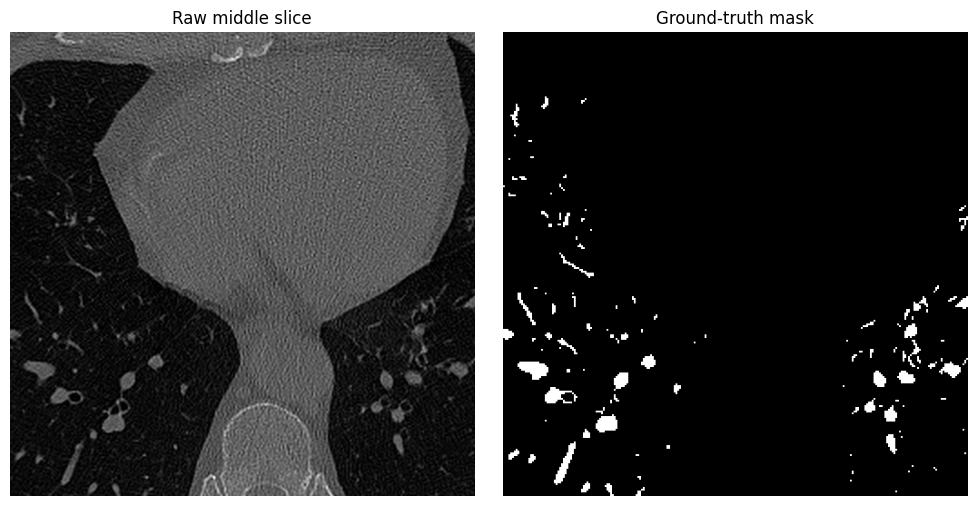

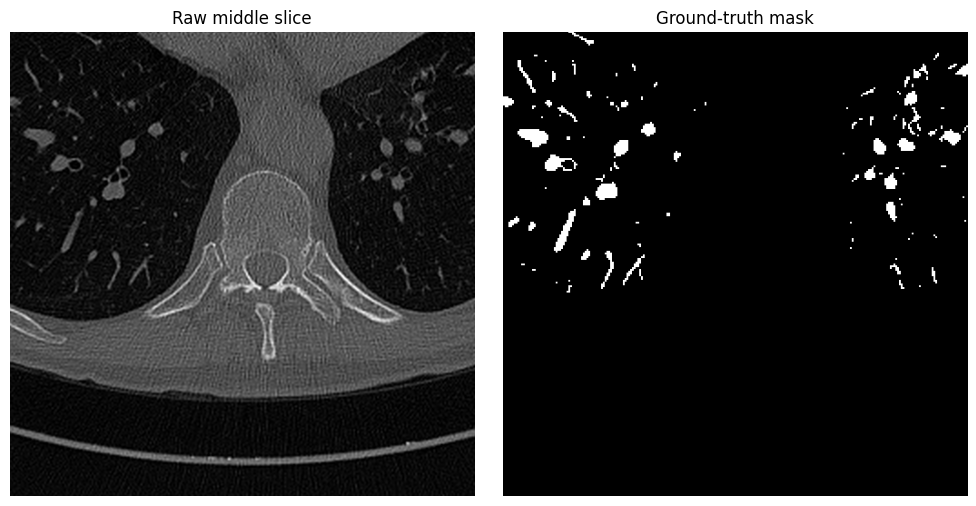

In [6]:
for case_id in preview_case_ids[:2]:
    pair = pairs_by_case[case_id]
    show_raw_mask_pair(pair.raw_path, pair.mask_path, channel_index=config.channel_index)


## Prepare nnU-Net Dataset

This converts the managed workspace copies of raw and mask volumes into nnU-Net format under `nnUNet_raw`, together with the exact split that preflight chose.


In [7]:
dataset_dir = prepare_nnunet_dataset(config, report=report)
dataset_dir


Prepared nnU-Net dataset: F:\DeepBranchAI\nnUNet_raw\Dataset3012_custom_finetune_demo
Training cases: 2
Split: 1 train / 1 val (auto_single_validation)


WindowsPath('F:/DeepBranchAI/nnUNet_raw/Dataset3012_custom_finetune_demo')

## Finetune

This is the only training block. It preprocesses the managed dataset, loads the DeepBranchAI pretrained checkpoint, fine-tunes it on your imported data, and stores the resulting checkpoint in the workspace.


In [8]:
import contextlib
import io
from IPython.display import Markdown, display

pretrained = ensure_pretrained_weights(config)

capture = io.StringIO()
with contextlib.redirect_stdout(capture), contextlib.redirect_stderr(capture):
    gpu_available = check_gpu()
    checkpoint = finetune_model(config)

if not gpu_available:
    raise RuntimeError('CUDA GPU not available. The demo finetune notebook expects a CUDA-capable GPU.')

captured = capture.getvalue()
if 'Fine-tuning already complete:' in captured:
    status = 'Using existing fine-tuned checkpoint.'
else:
    status = f'Fine-tuning complete for up to {config.max_epochs} epochs.'

display(Markdown(f'{status} Checkpoint ready: `{checkpoint}`'))


Using existing fine-tuned checkpoint. Checkpoint ready: `F:\DeepBranchAI\nnUNet_results\Dataset3012_custom_finetune_demo\nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres\fold_0\checkpoint_best.pth`

## Training Graphs

This displays the saved `progress.png` at 200 DPI from the finetuned output directory.


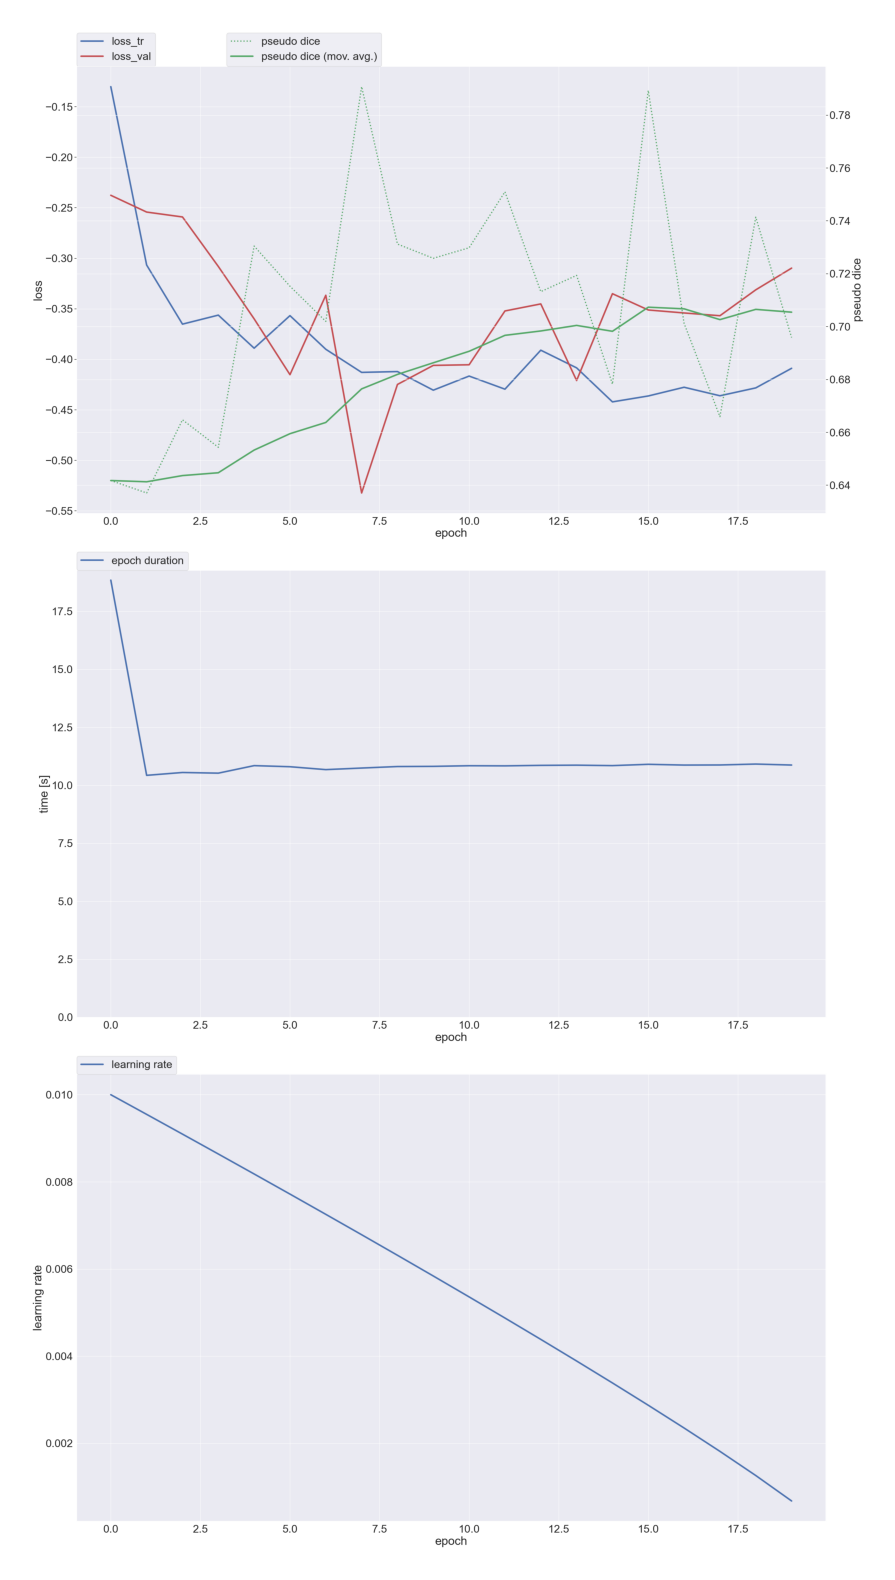

WindowsPath('F:/DeepBranchAI/nnUNet_results/Dataset3012_custom_finetune_demo/nnUNetTrainer_100epochs__nnUNetPlans__3d_fullres/fold_0/progress.png')

In [9]:
training_graph = show_training_graphs(config, dpi=200)
training_graph


## Run Inference

This block segments the managed copies of the inference volumes and writes TIFF masks to the configured output folder.


In [10]:
import contextlib
import io

capture = io.StringIO()
with contextlib.redirect_stdout(capture), contextlib.redirect_stderr(capture):
    predictions_dir = predict_with_finetuned_model(config)

print(f'Segmentation complete. Results saved to: {predictions_dir}')


Segmentation complete. Results saved to: F:\DeepBranchAI\data\custom_finetune\predictions


## Output Preview

This block shows the first segmentation result. If the inference volume matches a training case with ground truth, it shows raw, ground truth, and prediction. Otherwise it shows the raw inference volume and its prediction, then prints the output folder.


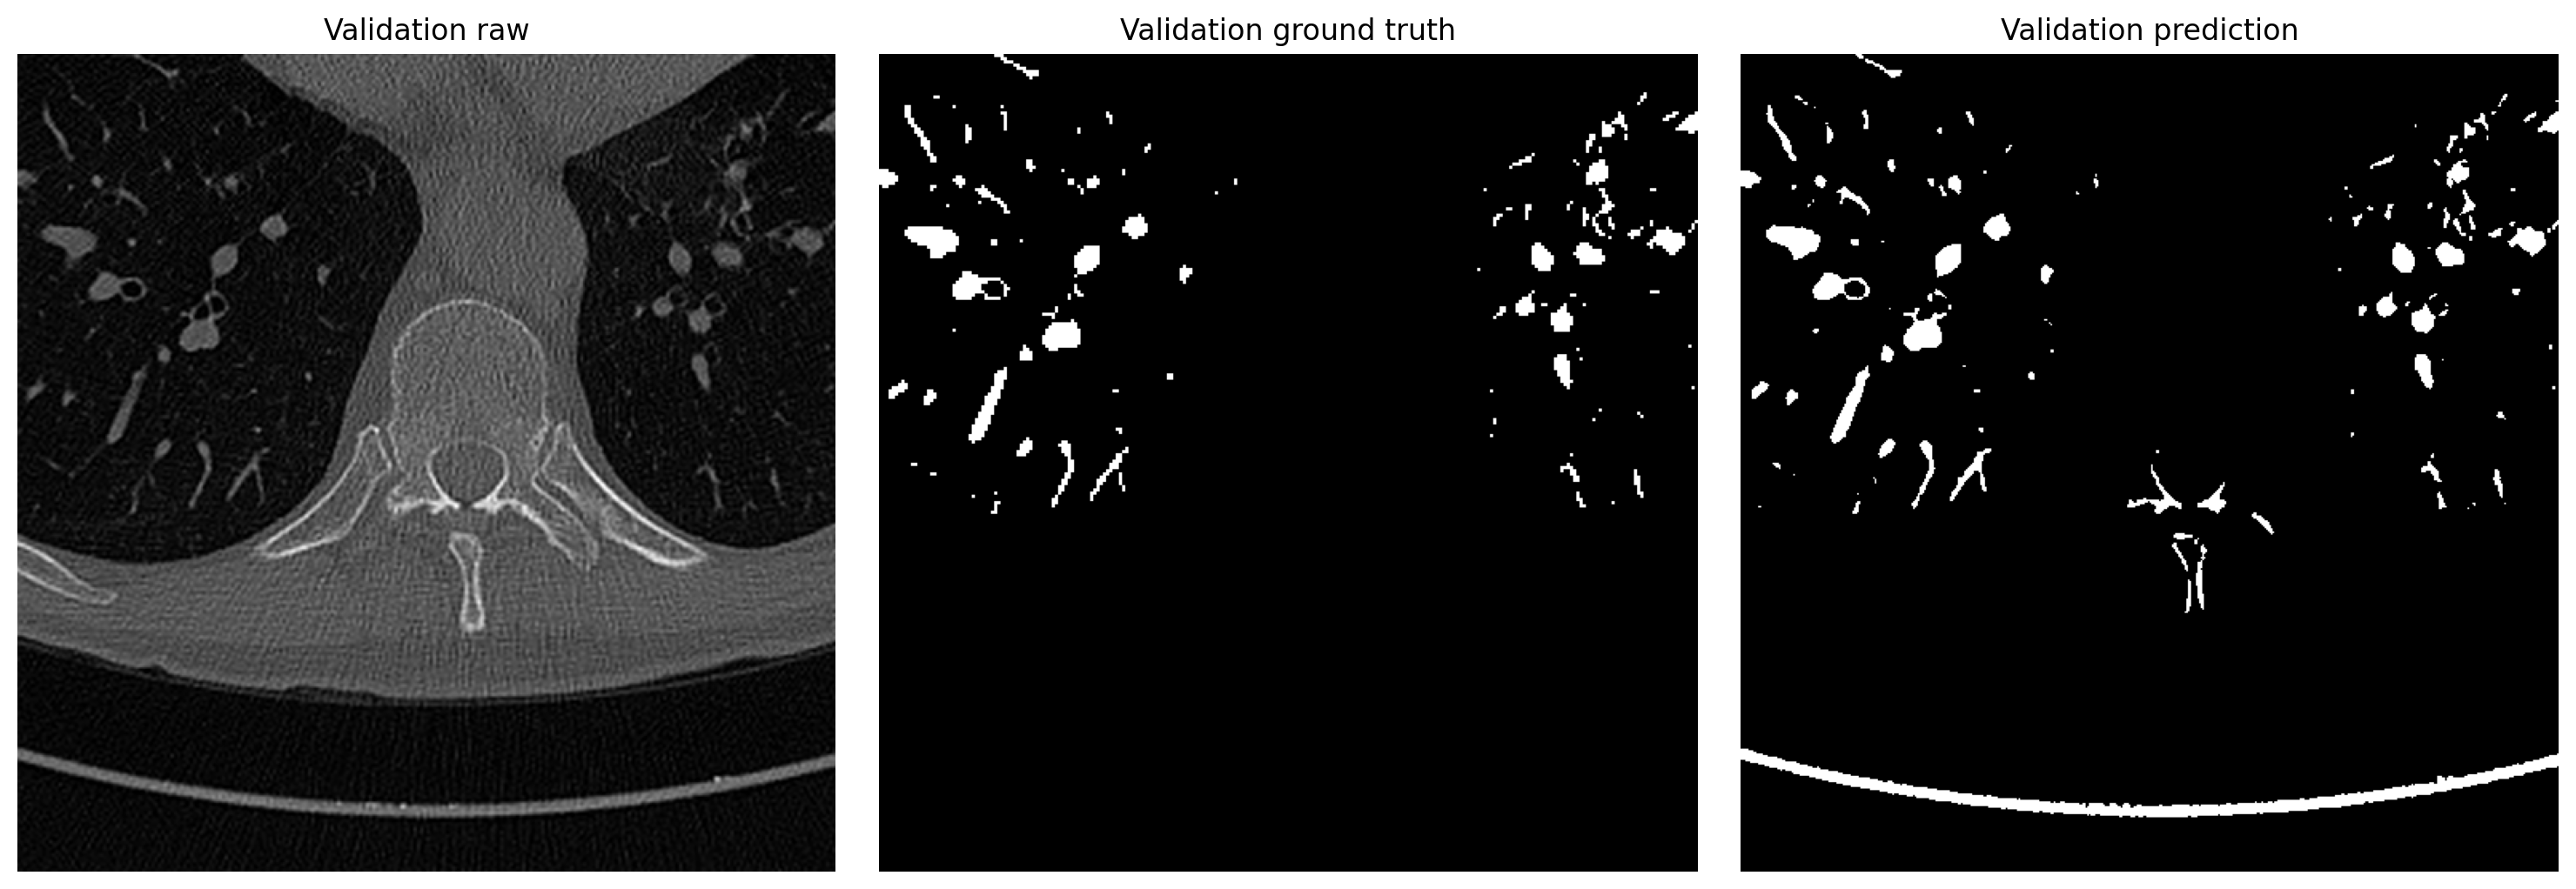

Segmentation TIFFs saved to: F:\DeepBranchAI\data\custom_finetune\predictions


WindowsPath('F:/DeepBranchAI/data/custom_finetune/predictions/mitochondria_00001_001.tif')

In [11]:
prediction_files = sorted(predictions_dir.glob('*.tif'))
if not prediction_files:
    raise ValueError(f'No TIFF predictions were produced in {predictions_dir}')

prediction_path = prediction_files[0]
inference_inputs = list_volume_files(config.predict_dir)
if not inference_inputs:
    raise ValueError(f'No inference inputs were found in {config.predict_dir}')
raw_input_path = inference_inputs[0]
case_id = volume_stem(raw_input_path)

if case_id in pairs_by_case:
    pair = pairs_by_case[case_id]
    show_validation_prediction_slice(
        pair.raw_path,
        pair.mask_path,
        prediction_path,
        channel_index=config.channel_index,
        dpi=200,
    )
else:
    show_raw_prediction_slice(
        raw_input_path,
        prediction_path,
        channel_index=config.channel_index,
        dpi=200,
    )

print(f'Segmentation TIFFs saved to: {predictions_dir}')
prediction_path


## Rename Guidance

If a mask is missing, use the same stem as the raw file. The managed workspace will rename masks to `_gt` automatically.
